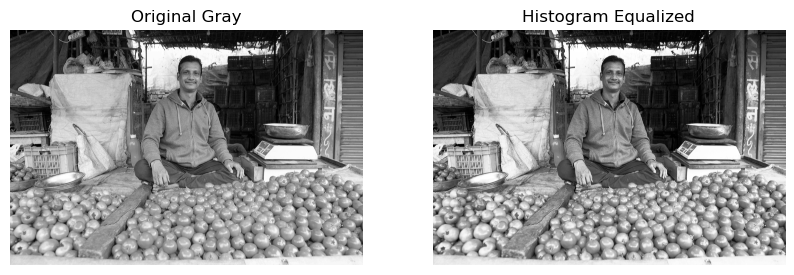

In [3]:
import cv2
from matplotlib import pyplot as plt

# Load image in grayscale
gray = cv2.imread("C:/Users/student/Pictures/51.jpg", cv2.IMREAD_GRAYSCALE)

# Apply Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Gray'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(equalized, cmap='gray'), plt.title('Histogram Equalized'), plt.axis('off')
plt.show()


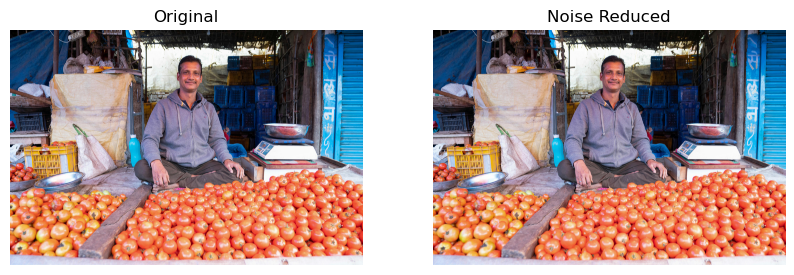

In [4]:
import cv2
from matplotlib import pyplot as plt

# Load image
image = cv2.imread('C:/Users/student/Pictures/51.jpg')

# Apply Gaussian Blur for noise reduction
denoised = cv2.GaussianBlur(image, (5, 5), 0)

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB)), plt.title('Noise Reduced'), plt.axis('off')
plt.show()


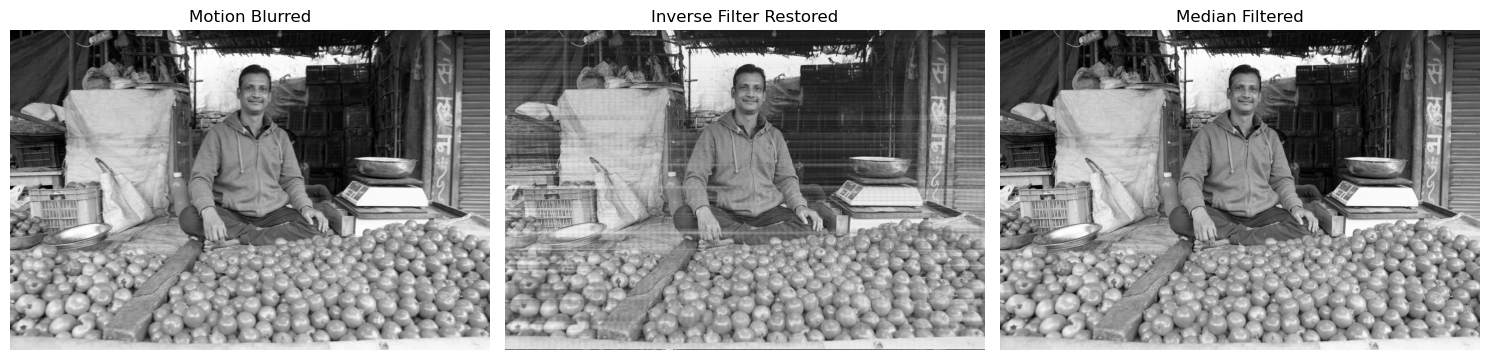

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ----------------------
# Simulate motion blur
def motion_blur_kernel(size):
    kernel = np.zeros((size, size))
    kernel[int((size-1)/2), :] = np.ones(size)
    return kernel / size

size = 15
psf = motion_blur_kernel(size)
blurred = cv2.filter2D(gray, -1, psf)

# Inverse filtering
def inverse_filter(img, psf):
    img_f = np.fft.fft2(img)
    psf_f = np.fft.fft2(psf, s=img.shape)
    psf_f[np.abs(psf_f) < 1e-3] = 1e-3  # Avoid division by zero
    result_f = img_f / psf_f
    result = np.abs(np.fft.ifft2(result_f))
    return np.uint8(np.clip(result, 0, 255))

restored = inverse_filter(blurred, psf)

# ----------------------
# Apply Median Filter
median_filtered = cv2.medianBlur(gray, 5)

# ----------------------
# Display all
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(blurred, cmap='gray'), plt.title('Motion Blurred'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(restored, cmap='gray'), plt.title('Inverse Filter Restored'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(median_filtered, cmap='gray'), plt.title('Median Filtered'), plt.axis('off')
plt.tight_layout()
plt.show()


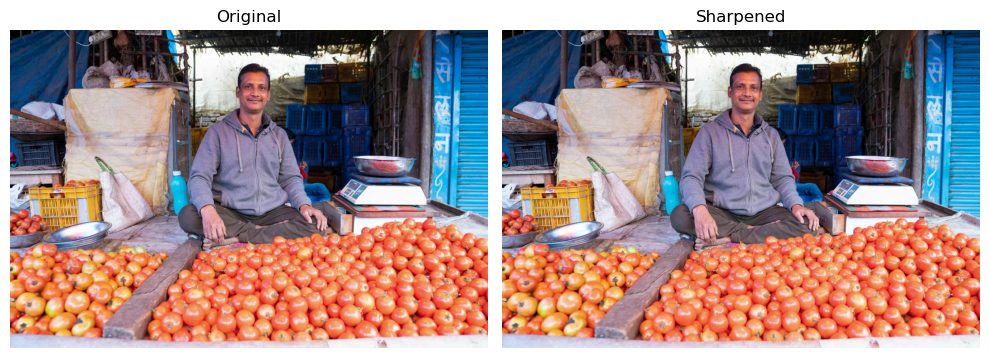

In [11]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image = cv2.imread('C:/Users/student/Pictures/51.jpg')

# Sharpening kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])

# Apply filter
sharpened = cv2.filter2D(image, -1, kernel)

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title("Original"), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)), plt.title("Sharpened"), plt.axis('off')
plt.tight_layout()
plt.show()


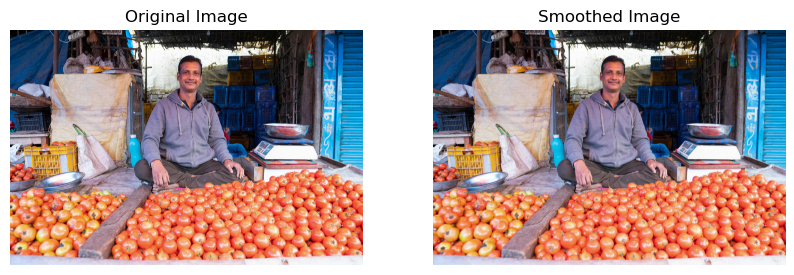

In [12]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image
image = cv2.imread('C:/Users/student/Pictures/51.jpg')  # Replace 'path_to_image.jpg' with your actual image path

# Convert the image from BGR to RGB (for matplotlib compatibility)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply GaussianBlur to smooth the image
smoothed_image = cv2.GaussianBlur(image_rgb, (15, 15), 0)

# Display the original and smoothed images
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

# Smoothed image
plt.subplot(1, 2, 2)
plt.imshow(smoothed_image)
plt.title('Smoothed Image')
plt.axis('off')

plt.show()


In [17]:
pip install scikit-image

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.9 MB 11.2 MB/s eta 0:00:01
   -------------- ------------------------- 4.7/12.9 MB 11.9 MB/s eta 0:00:01
   --------------------- ------------------ 7.1/12.9 MB 11.8 MB/s eta 0:00:01
   ------------------------------ --------- 9.7/12.9 MB 11.8 MB/s eta 0:00:01
   ------------------------------------- -- 12.1/12.9 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  12.8/12.9 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  12.8/12.9 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 8.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


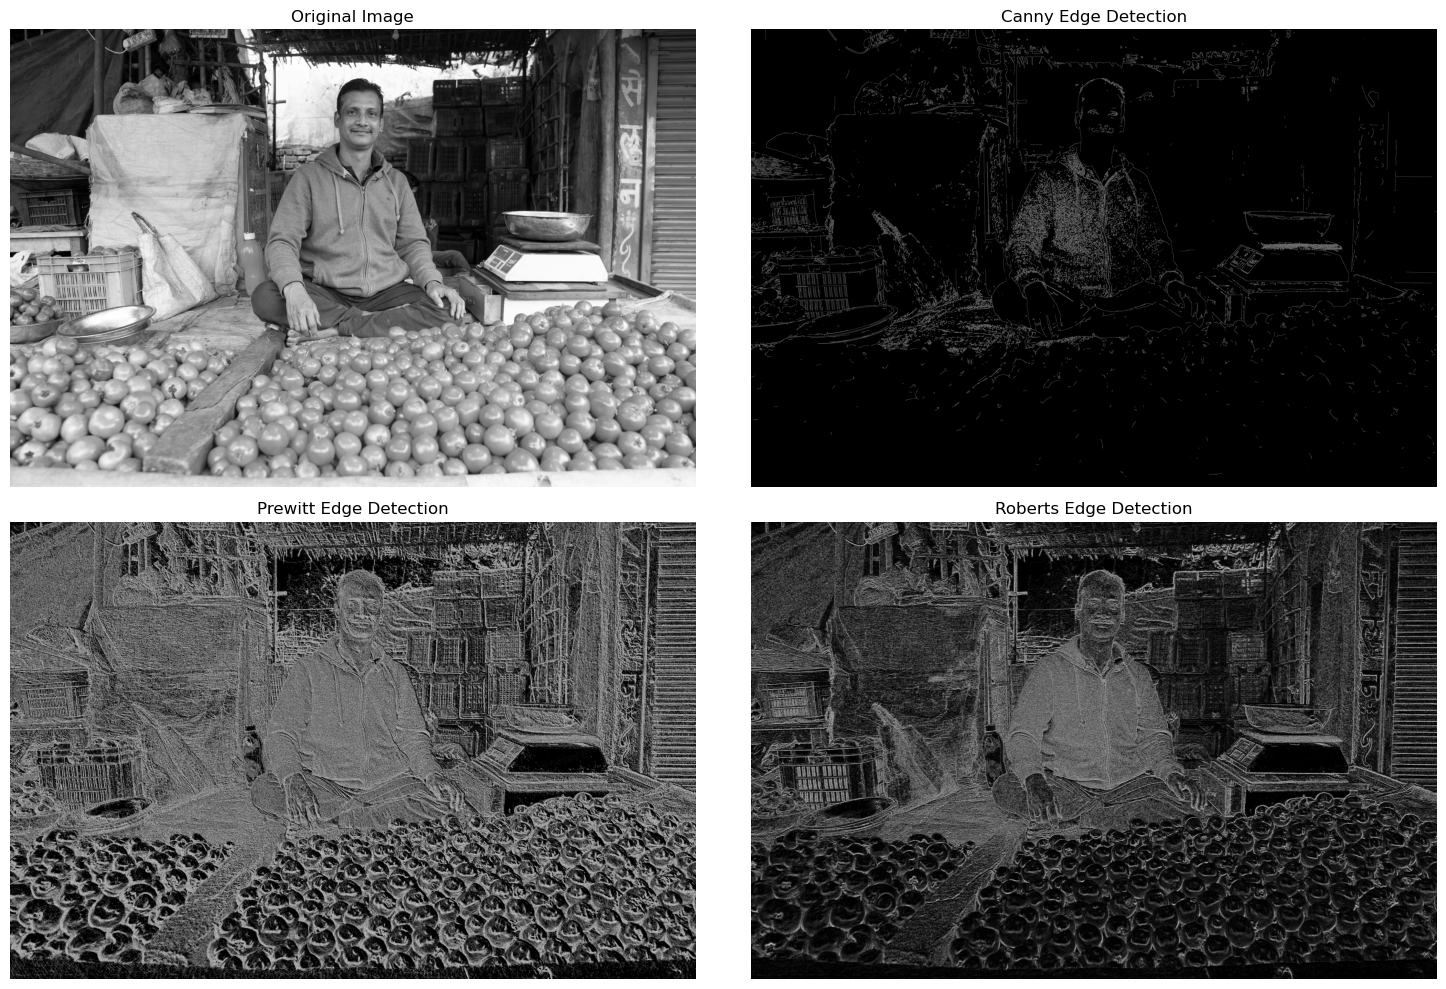

In [18]:
# Edge Detection using Canny, Prewitt, and Roberts Algorithms

import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image = cv2.imread('C:/Users/student/Pictures/51.jpg', cv2.IMREAD_GRAYSCALE)

# Display original image
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Canny Edge Detection
edges_canny = cv2.Canny(image, 100, 200)
plt.subplot(2, 2, 2)
plt.imshow(edges_canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

# Prewitt Edge Detection
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewittx = cv2.filter2D(image, -1, kernelx)
prewitty = cv2.filter2D(image, -1, kernely)
edges_prewitt = np.sqrt(prewittx**2 + prewitty**2)
plt.subplot(2, 2, 3)
plt.imshow(edges_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')

# Roberts Edge Detection
kernelx = np.array([[1, 0], [0, -1]])
kernely = np.array([[0, 1], [-1, 0]])
robertsx = cv2.filter2D(image, -1, kernelx)
robertsy = cv2.filter2D(image, -1, kernely)
edges_roberts = np.sqrt(robertsx**2 + robertsy**2)
plt.subplot(2, 2, 4)
plt.imshow(edges_roberts, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

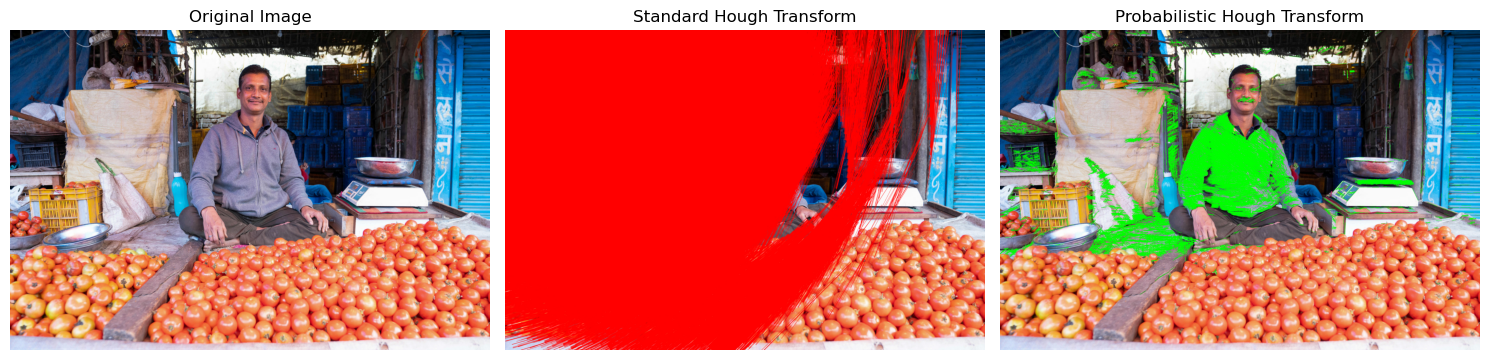

In [19]:
# Corner Detection using Hough Transform

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('C:/Users/student/Pictures/51.jpg', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Edge detection (Canny)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Standard Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=150)

# Draw lines on the original image
hough_image = image.copy()
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(hough_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Probabilistic Hough Line Transform (better for corners)
prob_hough_image = image.copy()
linesP = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=50, maxLineGap=10)

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(prob_hough_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(hough_image, cv2.COLOR_BGR2RGB))
plt.title('Standard Hough Transform')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(prob_hough_image, cv2.COLOR_BGR2RGB))
plt.title('Probabilistic Hough Transform')
plt.axis('off')

plt.tight_layout()
plt.show()

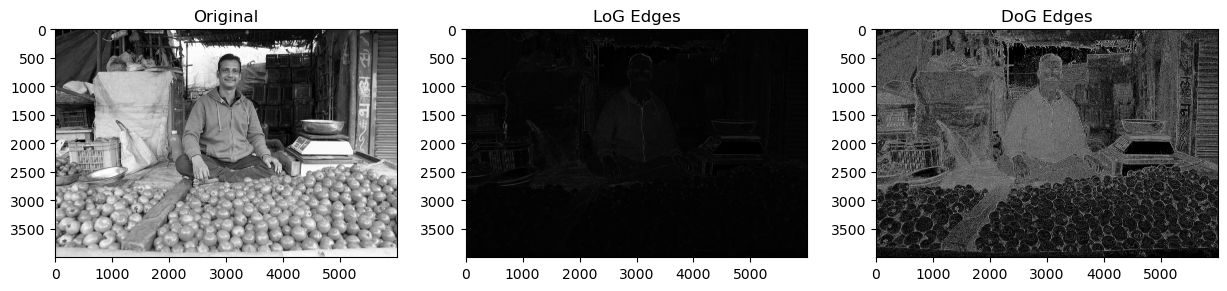

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread('C:/Users/student/Pictures/51.jpg', cv2.IMREAD_GRAYSCALE)

# Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(image, (5, 5), 1)

# Laplacian of Gaussian (LoG)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)
log_edges = np.uint8(np.absolute(laplacian))

# Difference of Gaussians (DoG)
gauss1 = cv2.GaussianBlur(image, (5, 5), 1)
gauss2 = cv2.GaussianBlur(image, (5, 5), 2)
dog_edges = np.uint8(np.abs(gauss1 - gauss2))

# Display results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(log_edges, cmap='gray'), plt.title('LoG Edges')
plt.subplot(1, 3, 3), plt.imshow(dog_edges, cmap='gray'), plt.title('DoG Edges')
plt.show()

In [22]:
!pip install torch torchvision


   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/204.1 MB 10.7 MB/s eta 0:00:19
    --------------------------------------- 4.5/204.1 MB 11.2 MB/s eta 0:00:18
   - -------------------------------------- 7.1/204.1 MB 11.5 MB/s eta 0:00:18
   - -------------------------------------- 9.7/204.1 MB 11.4 MB/s eta 0:00:18
   -- ------------------------------------- 12.1/204.1 MB 11.6 MB/s eta 0:00:17
   -- ------------------------------------- 14.4/204.1 MB 11.6 MB/s eta 0:00:17
   --- ------------------------------------ 17.0/204.1 MB 11.7 MB/s eta 0:00:17
   --- ------------------------------------ 19.7/204.1 MB 11.7 MB/s eta 0:00:16
   ---- ----------------------------------- 22.0/204.1 MB 11.7 MB/s eta 0:00:16
   ---- ----------------------------------- 24.4/204.1 MB 11.7 MB/s eta 0:00:16
   ----- ---------------------------------- 26.7/204.1 MB 11.6 MB/s eta 0:00:16
   ----- ---------------------------------- 29.1/204.

In [ ]:
# Mask R-CNN for Instance Segmentation
!pip install torch torchvision
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

# Load pretrained Mask R-CNN
model = maskrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load and preprocess image
img = Image.open("C:/Users/student/Pictures/51.jpg").convert("RGB")  # Replace with your image
img_tensor = torchvision.transforms.functional.to_tensor(img)

# Run inference
with torch.no_grad():
    predictions = model([img_tensor])

# Visualize masks and bounding boxes
mask_img = np.array(img)
for i in range(len(predictions[0]["masks"])):
    if predictions[0]["scores"][i] > 0.7:  # Confidence threshold
        mask = predictions[0]["masks"][i][0].numpy()
        mask_img = np.where(mask > 0.5, [0, 255, 0], mask_img)  # Green masks

plt.figure(figsize=(10, 6))
plt.imshow(mask_img)
plt.axis('off')
plt.title("Mask R-CNN Instance Segmentation")
plt.show()

C:\Users\student\.conda\envs\opencv_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\student\.conda\envs\opencv_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\student/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:15<00:00, 11.7MB/s] 
